# XGBoost (XGB)

In [1]:
import sys; sys.path.insert(0, "..")

from utils.dependencies import *
from utils import (
    load_and_filter, impute, split_and_balance, FEATURES,
    get_class_meta,
    run_grid_search,
    print_classification_report, compute_f1_scores, run_stratified_cv, print_error_patterns,
    plot_f1_bar, plot_confusion_matrices, plot_posterior_violins,
)

## Model-Specific Data Processing

In [2]:
df = load_and_filter()
df = impute(df)

LOG_COLS = ["pl_bmasse", "pl_orbper", "pl_orbsmax", "sy_dist"]
for col in LOG_COLS:
    df[col] = np.log1p(df[col].clip(lower=0))

# No clipping or scaling — tree ensembles split on raw thresholds.
X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, scaler = split_and_balance(
    df,
    scaler=StandardScaler(),
    smote_variant="standard",
)

class_names, classes, colors = get_class_meta()

Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features: 430 → 0 nulls
[Tier 5a] st_met: filled 424 via grouped median by spectral type
[Tier 5b] st_age: filled 1246 via RF regression + median fallback
[Tier 6] KNN imputer: 118 → 0 nulls

Train shape: (4455, 17)
Test shape:  (1114, 17)

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    300
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (699, 17)
Class weights: {np.int64(0): np.float64(0.7766666666666666), np.int64(1): np.float64(1.165), np.int64(2): np.float64(1.170854271356784)}

Outputs ready for modeling:
  X_train_bal       → (699, 17) (balanced, scaled)
  y_train_bal       → 699 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [3]:
# Stage 1: find n_estimators via early stopping
_X_tr, _X_val, _y_tr, _y_val = train_test_split(
    X_train_bal, y_train_bal, test_size=0.2, stratify=y_train_bal, random_state=42
)

_probe = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=5,
    early_stopping_rounds=50,
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0,
    n_jobs=-1,
)
_probe.fit(_X_tr, _y_tr, eval_set=[(_X_tr, _y_tr), (_X_val, _y_val)], verbose=False)
n_estimators_opt = _probe.best_iteration + 1
print(f"Early stopping: optimal n_estimators = {n_estimators_opt}")

# Stage 2: grid search over structural hyperparams
param_grid = {
    "learning_rate": [0.01, 0.1, 0.3],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
}

grid_xgb = run_grid_search(
    XGBClassifier(
        n_estimators=n_estimators_opt,
        importance_type="gain",
        random_state=42,
        verbosity=0,
        n_jobs=-1,
    ),
    param_grid,
    X_train_bal,
    y_train_bal,
)
xgb = grid_xgb.best_estimator_

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb  = xgb.predict_proba(X_test_scaled)

print(f"Best learning_rate:    {grid_xgb.best_params_['learning_rate']}")
print(f"Best max_depth:        {grid_xgb.best_params_['max_depth']}")
print(f"Best min_child_weight: {grid_xgb.best_params_['min_child_weight']}")
print(f"Best CV F1 Macro:      {grid_xgb.best_score_:.4f}")
print(f"n_estimators:          {xgb.n_estimators}  (early-stopping-optimal)")

Early stopping: optimal n_estimators = 46
Best learning_rate:    0.3
Best max_depth:        5
Best min_child_weight: 3
Best CV F1 Macro:      0.9884
n_estimators:          46  (early-stopping-optimal)


## Modeling
### DIAGNOSTIC PLOT 1: Feature Importances (Gain)

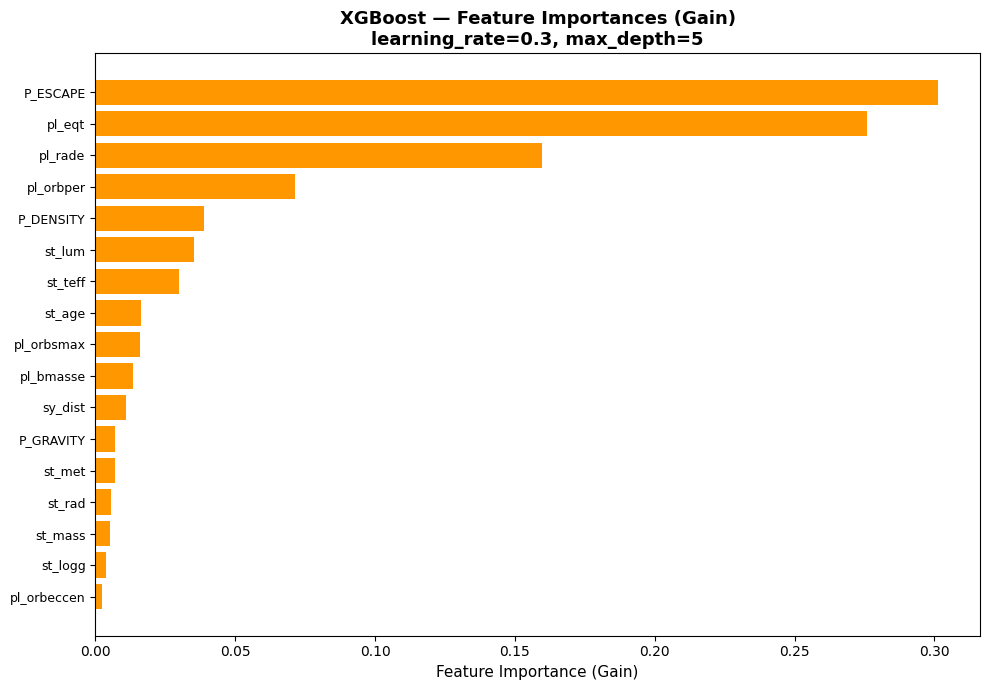

↑ Gain = total reduction in loss brought by splits on this feature across all trees.
  Unlike RF's Gini importance, gain is not normalised by how often the feature is used.
  Features with zero gain were never selected for a split.


In [4]:
feat_imp = xgb.feature_importances_
sorted_idx = np.argsort(feat_imp)[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(FEATURES)), feat_imp[sorted_idx], color="#FF9800", edgecolor="none")
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels([FEATURES[i] for i in sorted_idx], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (Gain)", fontsize=11)
ax.set_title(
    f"XGBoost — Feature Importances (Gain)\n"
    f"learning_rate={xgb.learning_rate}, max_depth={xgb.max_depth}",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
save_plot("xgb_feature_importances")
plt.show()

print("↑ Gain = total reduction in loss brought by splits on this feature across all trees.")
print("  Unlike RF's Gini importance, gain is not normalised by how often the feature is used.")
print("  Features with zero gain were never selected for a split.")

### DIAGNOSTIC PLOT 2: Learning Rate vs CV F1 Macro

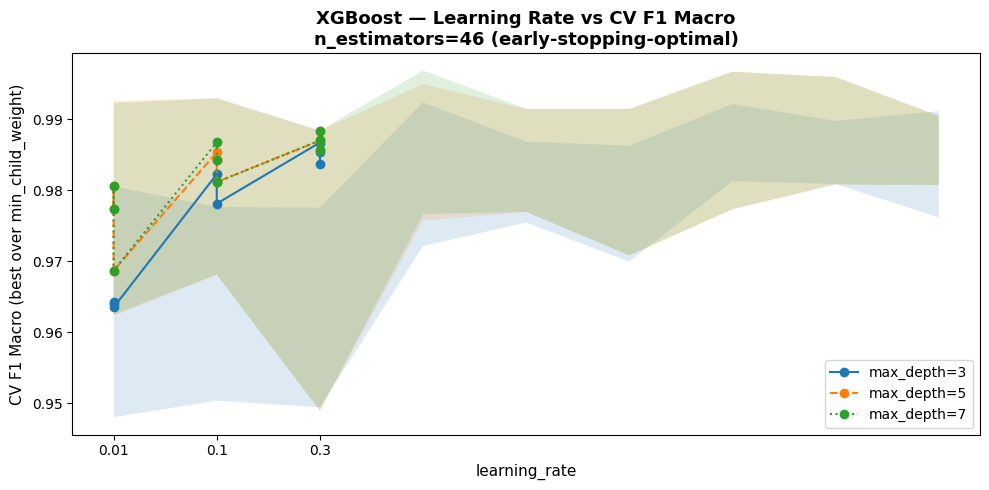

↑ Low learning_rate = smaller steps, needs more trees to converge (n_estimators already fixed).
  Shallow trees (max_depth=3) with low learning_rate = classic conservative boosting setup.
  Shaded band = ±1 std across CV folds.


In [5]:
results_df = pd.DataFrame(grid_xgb.cv_results_)

fig, ax = plt.subplots(figsize=(10, 5))
for depth, ls in [(3, "-"), (5, "--"), (7, ":")]:
    sub = results_df[results_df["param_max_depth"] == depth].sort_values("param_learning_rate")
    ax.plot(sub["param_learning_rate"].astype(str), sub["mean_test_score"],
            marker="o", ls=ls, label=f"max_depth={depth}")
    ax.fill_between(
        range(len(sub)),
        sub["mean_test_score"] - sub["std_test_score"],
        sub["mean_test_score"] + sub["std_test_score"],
        alpha=0.15,
    )

ax.set_xlabel("learning_rate", fontsize=11)
ax.set_ylabel("CV F1 Macro (best over min_child_weight)", fontsize=11)
ax.set_title(
    f"XGBoost — Learning Rate vs CV F1 Macro\n"
    f"n_estimators={xgb.n_estimators} (early-stopping-optimal)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("xgb_learning_rate_sensitivity")
plt.show()

print("↑ Low learning_rate = smaller steps, needs more trees to converge (n_estimators already fixed).")
print("  Shallow trees (max_depth=3) with low learning_rate = classic conservative boosting setup.")
print("  Shaded band = ±1 std across CV folds.")

### DIAGNOSTIC PLOT 3: Early Stopping Convergence

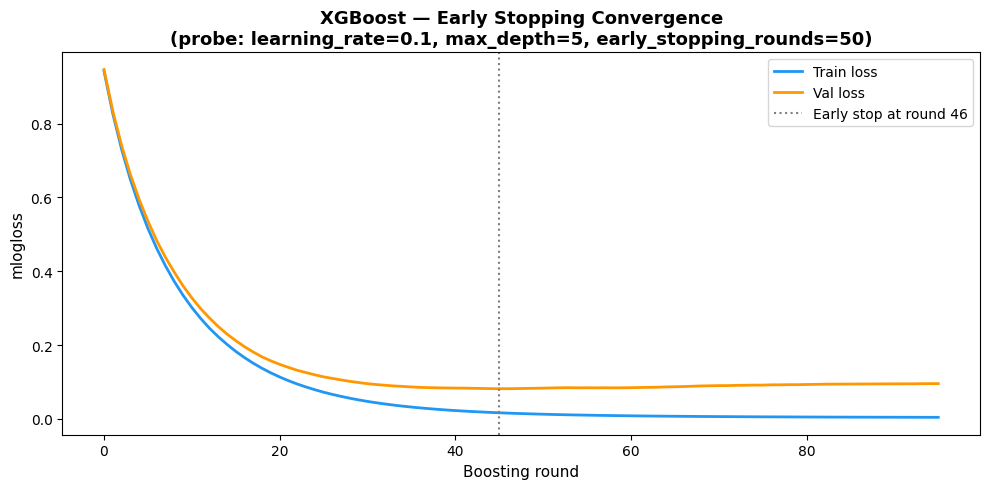

↑ Training stops when validation loss fails to improve for 50 consecutive rounds.
  Gap between train and val loss = overfitting — wider gap means the model memorised the training set.
  This is analogous to RF's OOB convergence: both find the point of diminishing returns.


In [6]:
_evals = _probe.evals_result()
_train_loss = _evals["validation_0"]["mlogloss"]
_val_loss   = _evals["validation_1"]["mlogloss"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(_train_loss, color="#2196F3", lw=2, label="Train loss")
ax.plot(_val_loss,   color="#FF9800", lw=2, label="Val loss")
ax.axvline(n_estimators_opt - 1, color="gray", ls=":", lw=1.5,
           label=f"Early stop at round {n_estimators_opt}")
ax.set_xlabel("Boosting round", fontsize=11)
ax.set_ylabel("mlogloss", fontsize=11)
ax.set_title(
    f"XGBoost — Early Stopping Convergence\n"
    f"(probe: learning_rate=0.1, max_depth=5, early_stopping_rounds=50)",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("xgb_early_stopping")
plt.show()

print("↑ Training stops when validation loss fails to improve for 50 consecutive rounds.")
print("  Gap between train and val loss = overfitting — wider gap means the model memorised the training set.")
print("  This is analogous to RF's OOB convergence: both find the point of diminishing returns.")

## Metrics
### Classification Report + F1 Scores

XGB — Classification Report
               precision    recall  f1-score   support

Non-Habitable     0.9991    0.9900    0.9945      1100
   Mesoplanet     0.6667    1.0000    0.8000         6
Psychroplanet     0.4000    0.7500    0.5217         8

     accuracy                         0.9883      1114
    macro avg     0.6886    0.9133    0.7721      1114
 weighted avg     0.9930    0.9883    0.9901      1114

F1 Macro:    0.7721
F1 Weighted: 0.9901

5-Fold CV F1 Macro: 0.9825 ± 0.0126
F1 Macro:    0.7721
F1 Weighted: 0.9901


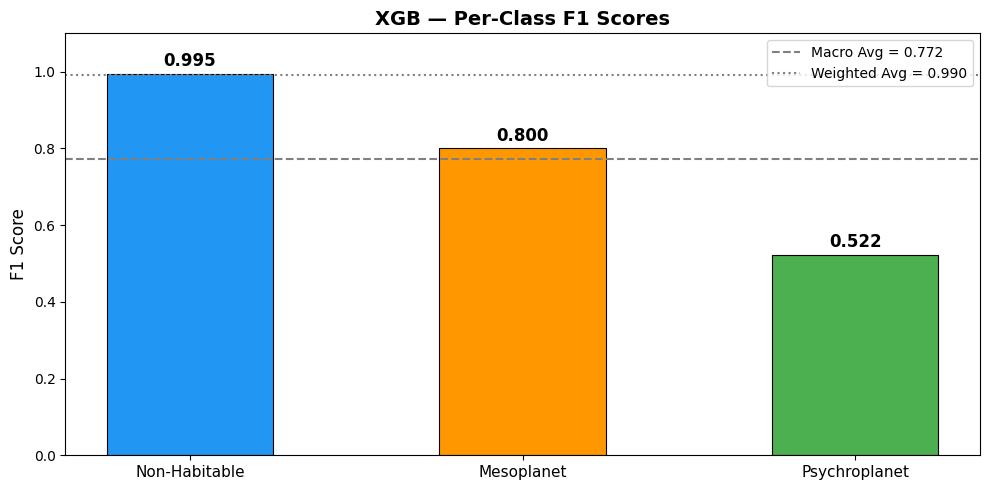

In [7]:
print_classification_report(y_test, y_pred_xgb, "XGB")

f1_macro_xgb, f1_weighted_xgb, _ = compute_f1_scores(y_test, y_pred_xgb)

cv_scores_xgb = run_stratified_cv(xgb, X_train_bal, y_train_bal)

plot_f1_bar(y_test, y_pred_xgb, "XGB")

### Confusion Matrices (Counts + Normalized)

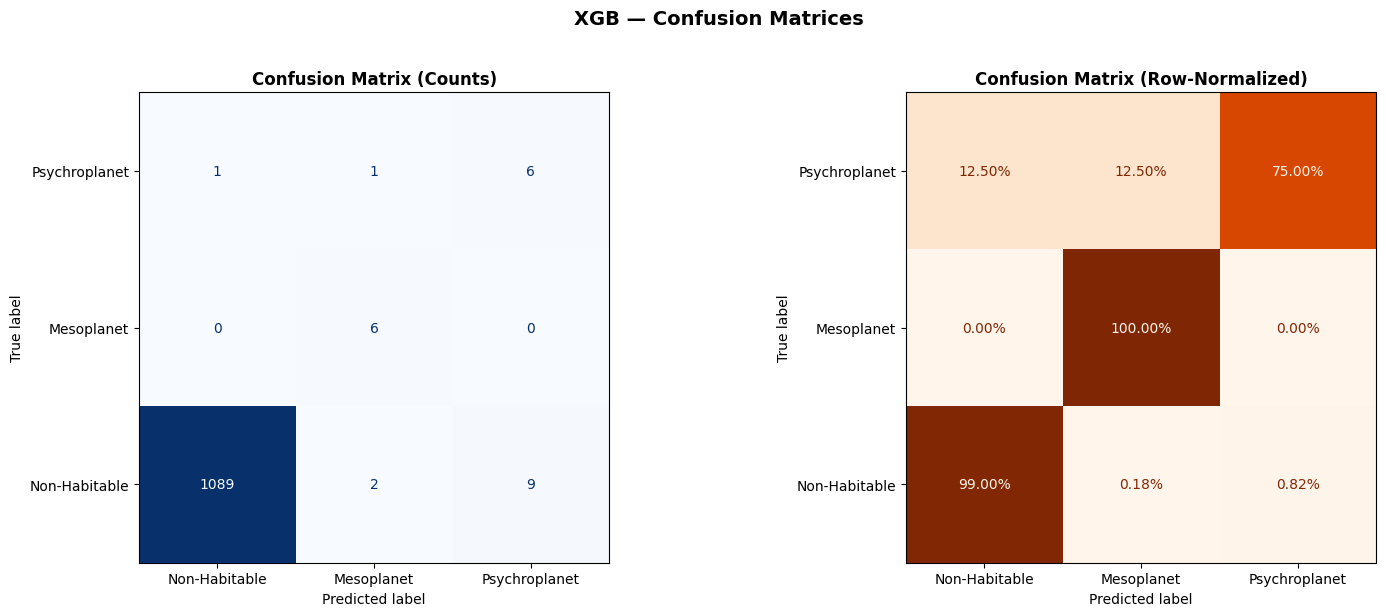

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 2 (0.2% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 9 (0.8% of true Non-Habitable)
  Psychroplanet → predicted Non-Habitable: 1 (12.5% of true Psychroplanet)
  Psychroplanet → predicted Mesoplanet: 1 (12.5% of true Psychroplanet)


In [8]:
plot_confusion_matrices(y_test, y_pred_xgb, "XGB")
print_error_patterns(y_test, y_pred_xgb)

## Interpretation: